This notebook **`demo_AmpelAccess.ipynb`** provides an end-to-end workflow for:

1. Load or create a local cache and synchronize it incrementally from the Hopskotch stream  
2. Inspect available classifiers and models  
3. Apply filters  
4. Generate review summaries for the full report set  
5. Generate a review summary for a single report  
6. Ingest and plot IceCube alerts  
7. Match and filter LSST reports against IceCube localization regions 

### 1. Obtain current AMPEL alert set (in teststream)

In this notebook, we use a cache system that stores the Kafka offset.  
When synchronizing the local dataset, the stream resumes from the last stored offset.


In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")

from pathlib import Path
from ampel_report_tools import AmpelReportSet
from icecube_tools import IceCubeAlert, iter_icecube_public_alerts, convert_txt_alerts_to_fits, load_icecube_skymaps



First, create the cache or load it if it already exists.

In [2]:
CACHE_ROOT = Path("./cache_ampelaccess")

if (CACHE_ROOT / "objects").exists():
    ars = AmpelReportSet.load_cache(CACHE_ROOT)
    print(f"Loaded cache: {len(ars)} objects")
else:
    ars = AmpelReportSet()
    CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    print("No cache yet, starting fresh")


No cache yet, starting fresh


To access the data stream, define the URL (host and topic) and a group ID.

The Kafka topic can be selected according to the astronomical objects of interest (refer to [https://ampelastro.github.io/LSST.html]):  
Extragalactic transients - **'ampel.lsst.extragalactic-transients'**   
Very young transients - **'ampel.lsst.extragalactic-infants'**  


The group ID identifies the Kafka consumer group.  
Kafka delivers only messages that are new for a given group.


The group ID **must** follow this format: <Hopskotch_credential_name>-<unique_suffix>

You can find your Hopskotch credential name in bash with:
```bash
hop auth list

In [ ]:
host = 'kafka://kafka.scimma.org/'
topic = 'ampel.lsst.extragalactic-transients'
topic_url = f"{host}{topic}"
group_id = "<Hopskotch_credential_name>-<unique_suffix>"

Now, we can update the cache with new reports from the stream.

In [13]:
stats = ars.update_from_stream(
    topic_url=topic_url,
    cache_root=CACHE_ROOT,
    group_id=group_id,
    start_at_if_new="EARLIEST",
    max_messages=None,
    persist=True,
)

print(stats)
ars.print_status()

{'n_messages': 0, 'n_objects_added': 0, 'n_objects_updated': 0, 'n_objects_total': 0}
AmpelReportSet status: 0 active / 0 total reports


### 2. Choose a classifier and model
Multiple classifiers and models may be available for different use cases.
In this section, select one of them.

Start by inspecting the classifiers and models available in the dataset.

In [14]:
_ = ars.print_classifiers_summary(active_only=True, model_index=0, cls_threshold=0.01)

Classifier summary (active_reports):
  n_total:                 0
  with classification:     0
  with >=1 model:          0
  class-key threshold:     p >= 0.01
  inspected model_index:   0

(no classifier/model occurrences)


Then choose the classifier and model to be used in the summary by referring to the indices listed above.

In [7]:
classifier = 0
model = 0

### 3. Adding Filters

The reports can be filtered using the following methods:

- `filter_class_prob(name, min_p, max_p)`  Select objects by class probability range.
- `filter_n_det(min_det, max_det, sigma_limit, band=None)`  Number of detections (SNR ≥ sigma), optional band.
- `filter_age(min_duration, max_duration, sigma_limit)`  Detection duration (days).
- `filter_time_since_first_det(min_days, max_days, sigma_limit, band=None)`  Time since first detection.
- `filter_time_since_last_det(min_days, max_days, sigma_limit, band=None)`  Time since last detection.
- `sigma_limit = 5.0` by default
- `filter_redshift(min_z, max_z)`  Host redshift.
- `filter_host_separation_arcsec(min_arcsec, max_arcsec)`  Transient–host angular separation (arcsec).
- `filter_sky_region(ra_range=(ra_min, ra_max), dec_range=(dec_min, dec_max))`  RA/Dec box (degrees).


- `clear_filters()`  Remove all active filters.
- `.active_filter_config` Read all active filters.


In [8]:
# Minimal SNIa probability
ars.filter_class_prob('P(SNIa)', min_prob=0.5, classifier=classifier, model=model)
ars.print_status()

AmpelReportSet status: 7 active / 370 total reports


In [8]:
# Minimal/maximal detections
ars.filter_n_det(min_det=10)
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [9]:
# Minimal transient duration
ars.filter_age(min_duration=7) # in days
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [10]:
# Time since first detection
ars.filter_time_since_first_det(max_days=1000)
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [11]:
# Time since last detection
ars.filter_time_since_last_det(max_days=1000)
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [12]:
# Minimal redshift
ars.filter_redshift(min_z=0.15)
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [13]:
# Maximal host separation
ars.filter_host_separation_arcsec(max_arcsec=10.0)
ars.print_status()

AmpelReportSet status: 7 active / 307 total reports


In [14]:
# Box sky region selection 
ars.filter_sky_region(ra_range=[-50,100], dec_range=[-50,30])
ars.print_status()

AmpelReportSet status: 6 active / 307 total reports


Filter presets are also available.  
At the moment, these are still preliminary and will be updated in `AmpelReportSet.py`.


In [15]:
#ars.apply_filter_preset("recent_young_highz_snia")
#ars.print_status()

You can inspect a summary of the currently active filter configuration.


In [16]:
print(ars.active_filter_config)

Filters: P(SNIa) ∈ [0.5, 1] | n_det ∈ [10, 1000000000] (σ≥5) | det duration ∈ [7, inf] d (σ≥5) | Δt(first det) ∈ [0, 1000] d (σ≥5) | Δt(last det) ∈ [0, 1000] d (σ≥5) | host z ∈ [0.15, inf] | host sep ∈ [0, 10] arcsec | sky RA∈[-50,100] DEC∈[-50,30]


Filters can be reset at any time, if desired.


In [17]:
#ars.clear_filters()
ars.print_status()

AmpelReportSet status: 6 active / 307 total reports


### 4. Access a set of Ampel Reports

A complete summary can be generated, where each row corresponds to one `LSSTReport`.


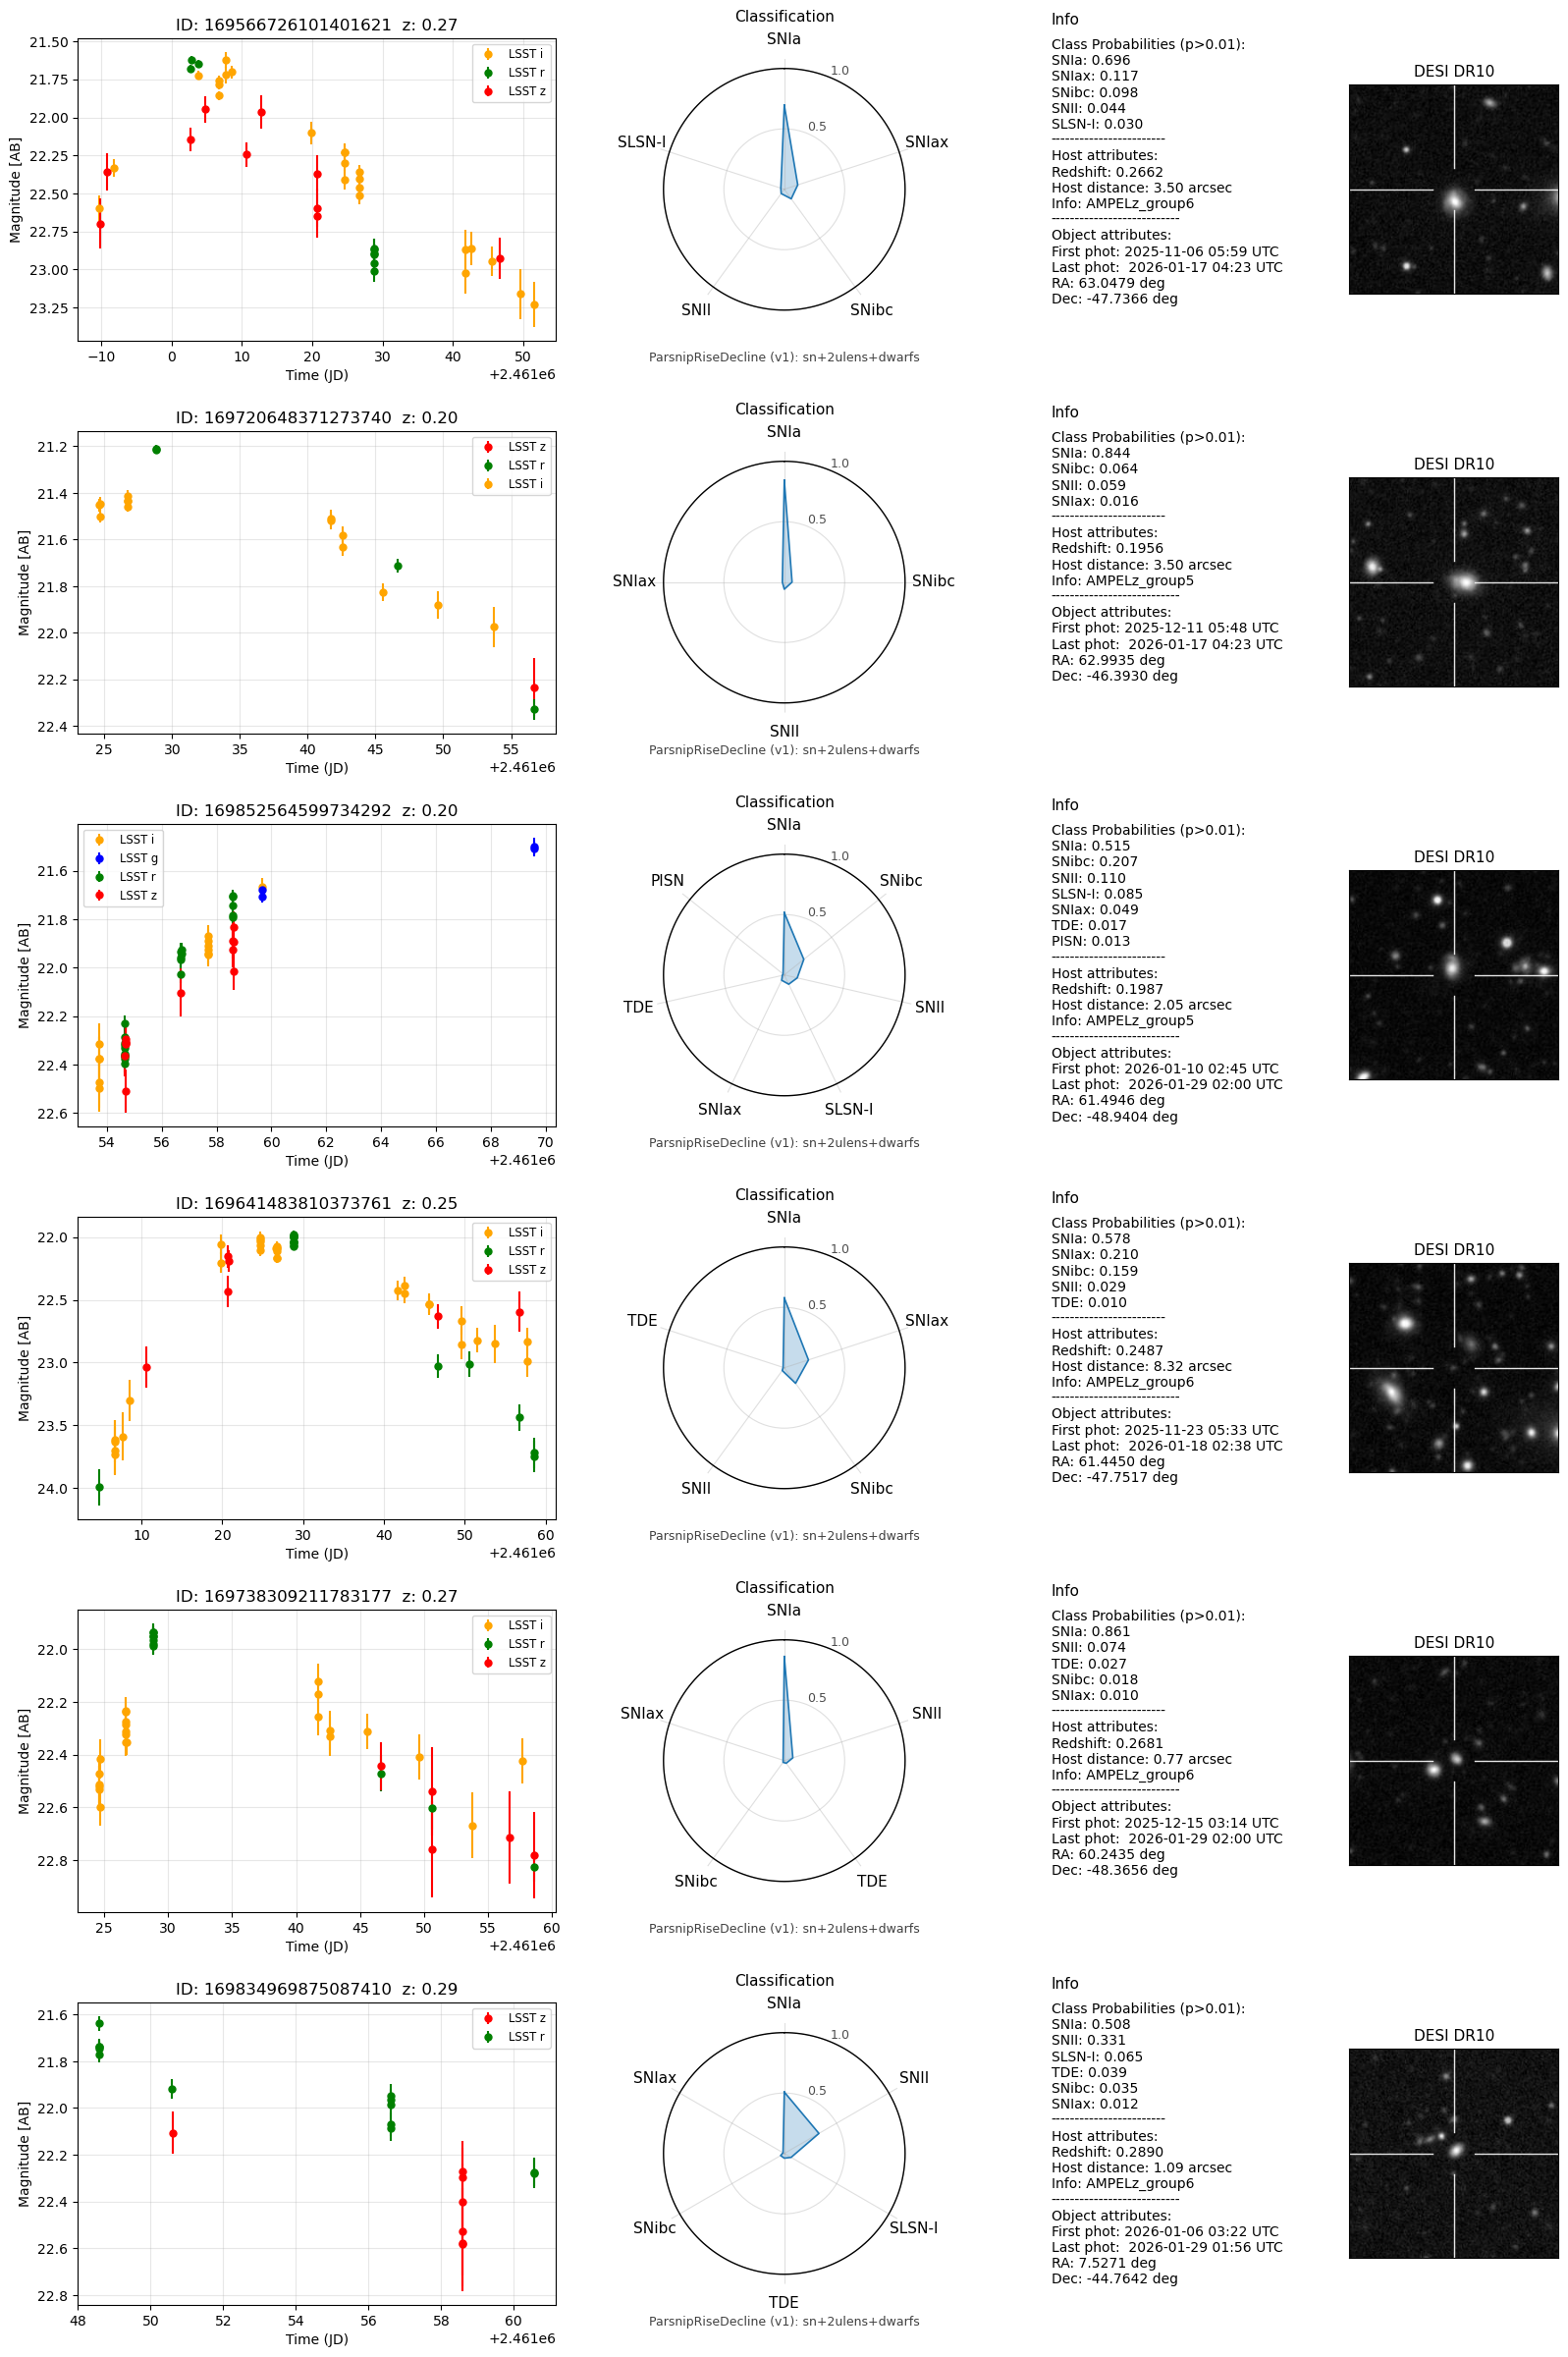

In [18]:
_ = ars.plot_summary_rows(classifier=classifier, model=model)

It is also possible to display individual components of the summary:
- All light curves  
- All info blocks (including finder stamps)  
- All classification panels 

In [19]:
#_ = ars.plot_lightcurves(grid=True,figsize=None)
#_ = ars.show_hosts(grid=True,figsize=None)
#_ = ars.show_classifications(grid=True,figsize=None,threshold=0.01)

### 5. Inspect the content of a single Ampel Report

Individual `LSSTReport` objects can be accessed and inspected in greater detail.


In [20]:
report=ars.active_reports[0] # The first row of the summary table
#report=ars._reports["169641483810373761"] # Or directly by a known ID

In [21]:
_ = report.inspect(snr_limit=5.0, cls_threshold=0.01) 


Top-level keys (6): classification, features, host, object, photometry, state
Object: id=169566726101401621  external_id=None
  RA/Dec: 63.04793, -47.73659 deg
Photometry: 45 pts  bands=['lssti', 'lsstr', 'lsstz']
  time: 2025-11-06 05:59 .. 2026-01-17 04:23 UTC
  detections (SNR≥5): 45  by band: {'lssti': 26, 'lsstr': 9, 'lsstz': 10}
Classification [0]: ParsnipRiseDecline (v1)  info='Trained on ELAsTiCC'
  Model (0): sn+2ulens+dwarfs
    SNIa          p=0.696
    SNIax         p=0.117
    SNibc         p=0.098
    SNII          p=0.044
    SLSN-I        p=0.030
Host:
  z = 0.2662
  distance = 3.50 arcsec
  info: 'AMPELz_group6'


In [22]:
report.phot_table[:5]

,time,flux,fluxerr,band,zp,zpsys
0,2.460986e+06,2825.722412,438.009003,lssti,31.4,ab
1,2.460990e+06,3313.195801,257.371124,lssti,31.4,ab
2,2.460990e+06,3025.736328,452.417145,lsstz,31.4,ab
3,2.460991e+06,4137.992188,466.031525,lsstz,31.4,ab
4,2.460992e+06,4245.535156,223.788635,lssti,31.4,ab


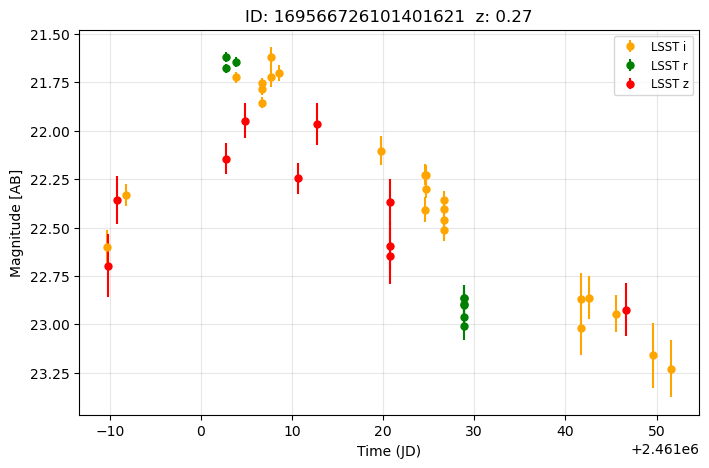

In [23]:
_ =report.plot_lightcurve()
#_ =report.show_classification()
#_ = report.show_hostinfo()
#_ = report.plot_summary_row()


### 6. Ingest IceCube alerts

For multi-messenger analyses, IceCube alerts can be incorporated either from local files or via public downloads.

As a first step, download all available ROC alerts.

In [24]:
available_icecube_alerts = list(iter_icecube_public_alerts())
print(available_icecube_alerts)

[{'healpix_url': './cache_ampelaccess/IceCubeAlerts/IceCube-260115A_skymap_probdensity_multiorder.fits.gz', 'event_name': 'IceCube-260115A'}, {'healpix_url': './cache_ampelaccess/IceCubeAlerts/IceCube-260125A_skymap_probdensity_multiorder.fits.gz', 'event_name': 'IceCube-260125A'}, {'healpix_url': './cache_ampelaccess/IceCubeAlerts/IceCube-260217A_skymap_probdensity_multiorder.fits.gz', 'event_name': 'IceCube-260217A'}]


Additionally, alerts can be added from local data, either as skymaps directly or as `.txt` / `.json` files that are converted into skymaps.

In [25]:
_ = convert_txt_alerts_to_fits("./cache_ampelaccess/IceCubeAlerts")
available_icecube_alerts = load_icecube_skymaps("./cache_ampelaccess/IceCubeAlerts")

To obtain an overview, we plot the alerts as Mollweide projections, including a zoomed-in view of the localization region.


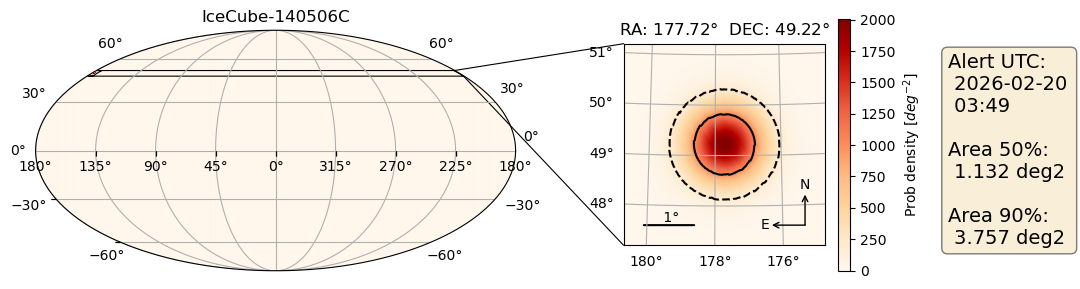

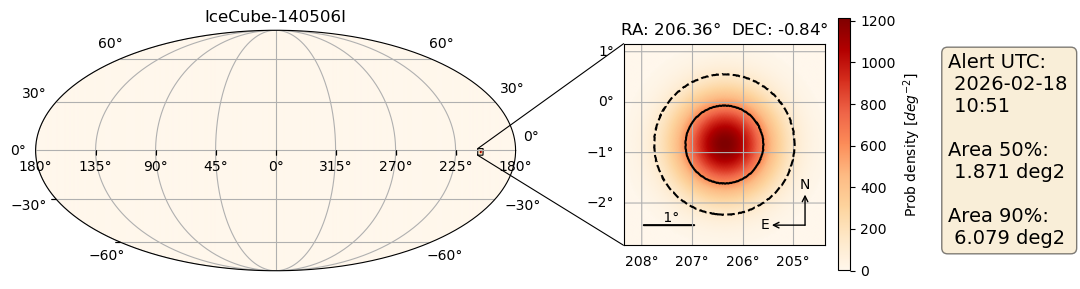

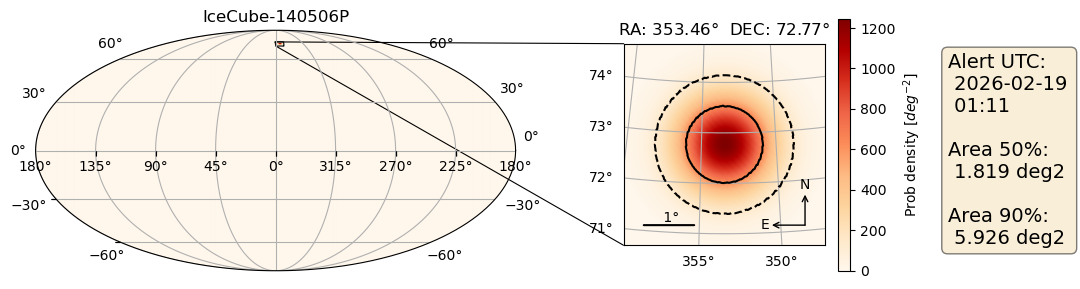

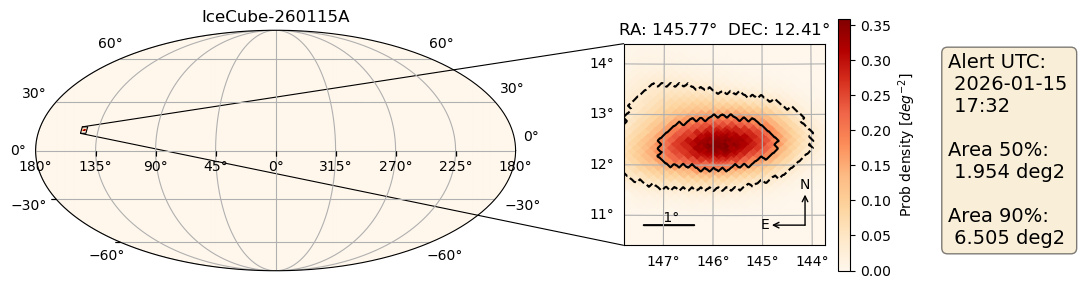

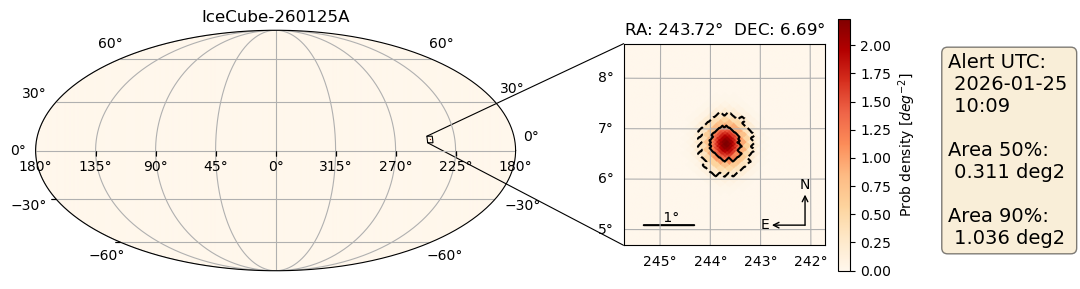

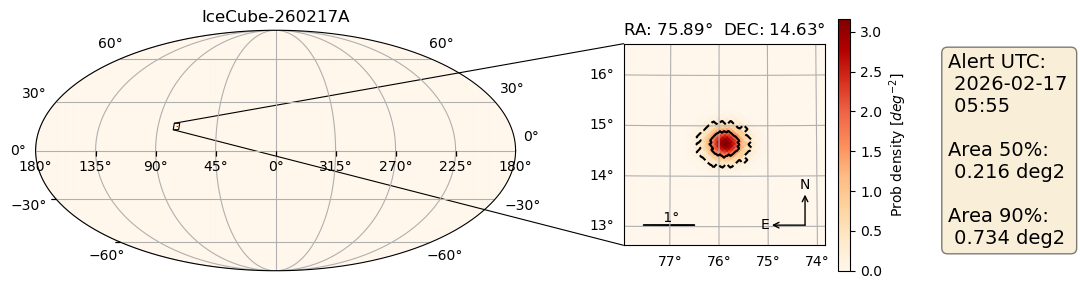

In [26]:
for a in available_icecube_alerts:
    IceCubeAlert.from_dict(a).plot(r=2, show_alert_datetime=True)

Alerts can also be plotted individually.

In [27]:
ic_alert= IceCubeAlert.from_dict(available_icecube_alerts[1])
#ic_alert.plot(r=2)
#ic_alert.plot(r=2, zoom=True)

To get an intuition for multi-messenger analyses, we can test whether given coordinates fall within a chosen cumulative probability region.


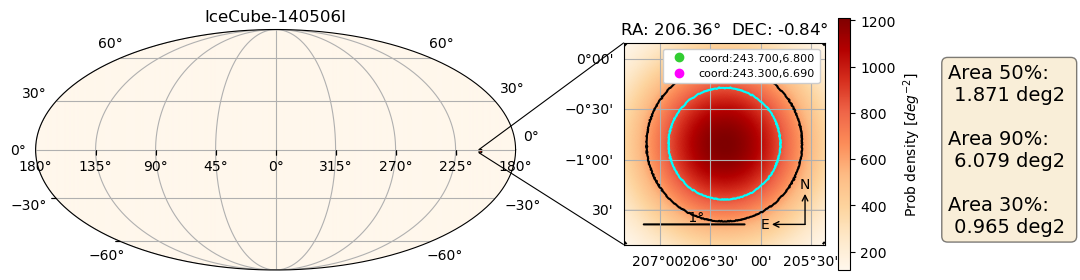

{'coord:243.700,6.800': False, 'coord:243.300,6.690': False}

In [28]:
source_1 = (243.7,6.8 )
source_2 = (243.3,6.69)
ic_alert.contains_source(sources=[source_1, source_2], p_region=0.3, r=1)

### 7. Filter LSST reports based on IceCube alerts

With a set of IceCube alerts and a set of LSST objects, we can check for matches in the stream.


In [29]:
ars.clear_filters()
ars.print_status()
print(len(available_icecube_alerts))

AmpelReportSet status: 307 active / 307 total reports
6


The following plot provides an overview of the current objects on the sky.

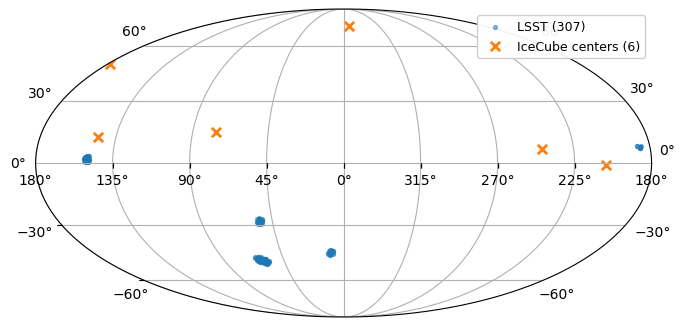

In [30]:
fig, ax = ars.plot_sky_mollweide(alpha_lsst=0.5, icecube_alerts=available_icecube_alerts, map_dir="./cache_ampelaccess/IceCubeAlerts")

Based on the probability region and the chosen time window, LSST reports can be associated with IceCube alerts.

In [31]:
ic_to_objs, _ = ars.match_lsst_to_icecube_alerts(
    available_icecube_alerts,
    p_region=0.99,
    #max_days_before=10, #first detection of LSST object to IceCube alert
    #max_days_after=30,
    verbose=False, 
    drop_empty=False)

for ic_id, objs in ic_to_objs.items():
    print(ic_id, objs)


IceCube-140506C []
IceCube-140506I []
IceCube-140506P []
IceCube-260115A []
IceCube-260125A []
IceCube-260217A []


The active LSST report set can then be filtered to include only objects contained in an IceCube localization region.

In [32]:
ic_alert = IceCubeAlert.from_dict(available_icecube_alerts[1])

ars.filter_icecube_region(
    ic_alert, 
    p_region=0.99,
    max_days_before=10,
    max_days_after=30, 
    map_dir="./cache_ampelaccess/IceCubeAlerts")
ars.print_status()

AmpelReportSet status: 0 active / 307 total reports


Finally, we can visualize the filtered set as a Mollweide projection.  
Note: this step will fail if the report set is empty.

In [33]:
#ic_alert.contains_source(sources=ars.active_reports, p_region=0.3, r=1)